DATA MINAT MAHASISWA


,Basis Data,Pemrograman Web,Jaringan Komputer,Sistem Operasi,Analisis Data,Kecerdasan Buatan,UI/UX,Keamanan Siber,Manajemen Proyek,Pemrograman Mobile
Mahasiswa_1,5,0,3,3,4,5,0,0,3,3
Mahasiswa_2,4,4,0,2,5,5,0,3,0,4
Mahasiswa_3,2,0,5,0,3,0,3,5,3,2
Mahasiswa_4,0,2,0,4,0,2,2,5,4,3
Mahasiswa_5,5,5,4,0,3,0,2,0,2,4
Mahasiswa_6,4,3,0,3,5,0,2,3,3,0
Mahasiswa_7,2,4,4,4,0,3,3,5,0,0
Mahasiswa_8,0,3,5,4,2,0,3,5,4,0
Mahasiswa_9,0,4,2,3,3,5,2,0,3,0
Mahasiswa_10,4,4,2,0,0,5,2,3,0,4



Keterangan nilai:
1 = Sangat tidak tertarik
2 = Kurang tertarik
3 = Cukup tertarik
4 = Tertarik
5 = Sangat tertarik
0 = Belum memberikan penilaian

HASIL PENCARIAN MAHASISWA YANG MIRIP
Mahasiswa target: Mahasiswa_1

Mahasiswa yang memiliki pola minat paling mirip:
- Mahasiswa_13 | Similarity = 0.9315
- Mahasiswa_18 | Similarity = 0.9185
- Mahasiswa_2 | Similarity = 0.7800
- Mahasiswa_12 | Similarity = 0.7565
- Mahasiswa_17 | Similarity = 0.7540

Mata kuliah yang belum dinilai oleh mahasiswa:
- Pemrograman Web
- UI/UX
- Keamanan Siber

HASIL REKOMENDASI MATA KULIAH


,Mata Kuliah,Skor Rekomendasi
1,Pemrograman Web,4.000000
2,Keamanan Siber,3.000000
3,UI/UX,2.225111


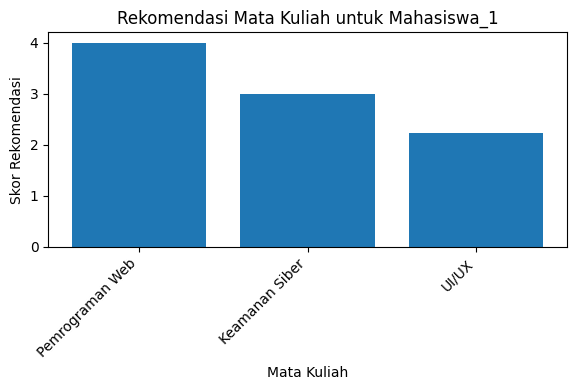


KESIMPULAN HASIL REKOMENDASI
Mahasiswa yang dianalisis: Mahasiswa_1
Sistem memberikan rekomendasi berdasarkan kemiripan pola minat dengan mahasiswa lain.

Mata kuliah yang direkomendasikan:
1. Pemrograman Web (Skor: 4.00)
2. Keamanan Siber (Skor: 3.00)
3. UI/UX (Skor: 2.23)


In [6]:
# ============================================================
# SISTEM REKOMENDASI MATA KULIAH
# Machine Learning - KNN + Cosine Similarity
# ============================================================

# ============================================================
# 1. IMPORT LIBRARY
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import NearestNeighbors


# ============================================================
# 2. MEMBUAT DATA MATA KULIAH
# ============================================================

courses = [
    "Basis Data",
    "Pemrograman Web",
    "Jaringan Komputer",
    "Sistem Operasi",
    "Analisis Data",
    "Kecerdasan Buatan",
    "UI/UX",
    "Keamanan Siber",
    "Manajemen Proyek",
    "Pemrograman Mobile"
]


# ============================================================
# 3. MEMBUAT POLA MINAT MAHASISWA
# ============================================================
# Nilai:
# 1 = sangat tidak tertarik
# 2 = kurang tertarik
# 3 = cukup tertarik
# 4 = tertarik
# 5 = sangat tertarik
#
# Nilai 0 berarti mahasiswa belum memberikan penilaian.


profiles = [
    # Basis Data, Web, Jaringan, OS, Analisis Data,
    # AI, UI/UX, Keamanan Siber, Manajemen Proyek, Mobile

    [5, 5, 3, 3, 4, 5, 2, 3, 3, 4],
    [4, 4, 3, 3, 5, 5, 2, 3, 3, 4],
    [2, 3, 5, 4, 2, 2, 3, 5, 3, 2],
    [3, 3, 5, 4, 2, 2, 3, 5, 4, 2]
]


# ============================================================
# 4. MEMBUAT DATA 20 MAHASISWA
# ============================================================

ratings = []

for i in range(20):

    # Mengambil salah satu pola minat
    base = np.array(profiles[i % 4], dtype=float)

    # Membuat variasi kecil agar data setiap mahasiswa
    # tidak benar-benar sama
    rng = np.random.default_rng(i)

    noise = rng.normal(
        loc=0,
        scale=0.4,
        size=len(courses)
    )

    # Menambahkan variasi dan membulatkan nilai
    rating = np.clip(
        np.rint(base + noise),
        1,
        5
    ).astype(int)

    # Menentukan 3 mata kuliah yang belum dinilai
    missing_rng = np.random.default_rng(100 + i)

    missing_courses = missing_rng.choice(
        len(courses),
        size=3,
        replace=False
    )

    # Nilai 0 berarti belum memberikan penilaian
    rating[missing_courses] = 0

    ratings.append(rating)


# ============================================================
# 5. MEMBUAT DATAFRAME
# ============================================================

df = pd.DataFrame(
    ratings,
    index=[
        f"Mahasiswa_{i+1}"
        for i in range(20)
    ],
    columns=courses
)


# ============================================================
# 6. MENAMPILKAN DATA
# ============================================================

print("=" * 70)
print("DATA MINAT MAHASISWA")
print("=" * 70)

display(df)


# ============================================================
# 7. PENJELASAN NILAI
# ============================================================

print("\nKeterangan nilai:")
print("1 = Sangat tidak tertarik")
print("2 = Kurang tertarik")
print("3 = Cukup tertarik")
print("4 = Tertarik")
print("5 = Sangat tertarik")
print("0 = Belum memberikan penilaian")


# ============================================================
# 8. MEMBUAT MODEL KNN
# ============================================================
# Cosine digunakan untuk mengukur kemiripan pola minat
# antar mahasiswa.

model = NearestNeighbors(
    metric="cosine",
    algorithm="brute",
    n_neighbors=6
)

model.fit(df.values)


# ============================================================
# 9. FUNGSI REKOMENDASI
# ============================================================

def recommend_courses(
    target_student,
    k=5,
    top_n=5
):

    # Mengecek apakah nama mahasiswa tersedia
    if target_student not in df.index:
        print("Mahasiswa tidak ditemukan.")
        return None

    # Mendapatkan posisi mahasiswa
    target_index = df.index.get_loc(target_student)

    # Mengambil data mahasiswa target
    target_vector = df.loc[
        target_student
    ].values.reshape(1, -1)

    # Mencari mahasiswa yang paling mirip
    distances, indices = model.kneighbors(
        target_vector,
        n_neighbors=k + 1
    )

    # Mahasiswa pertama adalah dirinya sendiri,
    # sehingga tidak digunakan sebagai tetangga.
    neighbor_indices = indices[0][1:]

    neighbor_distances = distances[0][1:]

    # Cosine distance diubah menjadi similarity
    similarities = 1 - neighbor_distances


    # ========================================================
    # 10. MENAMPILKAN MAHASISWA YANG PALING MIRIP
    # ========================================================

    print("\n" + "=" * 70)
    print("HASIL PENCARIAN MAHASISWA YANG MIRIP")
    print("=" * 70)

    print(
        "Mahasiswa target:",
        target_student
    )

    print("\nMahasiswa yang memiliki pola minat paling mirip:")

    for idx, similarity in zip(
        neighbor_indices,
        similarities
    ):

        print(
            f"- {df.index[idx]} "
            f"| Similarity = {similarity:.4f}"
        )


    # ========================================================
    # 11. MENCARI MATA KULIAH YANG BELUM DINILAI
    # ========================================================

    target_ratings = df.loc[target_student]

    candidate_courses = [
        course
        for course in courses
        if target_ratings[course] == 0
    ]


    print("\nMata kuliah yang belum dinilai oleh mahasiswa:")

    if len(candidate_courses) == 0:

        print("- Tidak ada")

    else:

        for course in candidate_courses:
            print("-", course)


    # ========================================================
    # 12. MENGHITUNG SKOR REKOMENDASI
    # ========================================================

    results = []

    for course in candidate_courses:

        course_index = courses.index(course)

        weighted_sum = 0
        similarity_sum = 0

        # Melihat penilaian dari mahasiswa yang mirip
        for idx, similarity in zip(
            neighbor_indices,
            similarities
        ):

            rating = df.iloc[
                idx,
                course_index
            ]

            # Hanya menggunakan rating yang tersedia
            if rating > 0:

                weighted_sum += (
                    similarity * rating
                )

                similarity_sum += similarity


        # Menghitung rata-rata berbobot
        if similarity_sum > 0:

            score = (
                weighted_sum /
                similarity_sum
            )

            results.append(
                (
                    course,
                    score
                )
            )


    # ========================================================
    # 13. MEMBUAT HASIL REKOMENDASI
    # ========================================================

    if len(results) == 0:

        print(
            "\nTidak dapat membuat rekomendasi."
        )

        return None


    result_df = pd.DataFrame(
        results,
        columns=[
            "Mata Kuliah",
            "Skor Rekomendasi"
        ]
    )


    # Mengurutkan dari skor tertinggi
    result_df = result_df.sort_values(
        by="Skor Rekomendasi",
        ascending=False
    )


    # Mengambil Top-N rekomendasi
    result_df = result_df.head(top_n)


    # Mengatur nomor urut
    result_df = result_df.reset_index(
        drop=True
    )

    result_df.index = result_df.index + 1


    # ========================================================
    # 14. MENAMPILKAN HASIL
    # ========================================================

    print("\n" + "=" * 70)
    print("HASIL REKOMENDASI MATA KULIAH")
    print("=" * 70)

    display(result_df)


    # ========================================================
    # 15. VISUALISASI HASIL
    # ========================================================

    plt.figure(figsize=(6, 5))

    plt.bar(
        result_df["Mata Kuliah"],
        result_df["Skor Rekomendasi"]
    )

    plt.xlabel(
        "Mata Kuliah"
    )

    plt.ylabel(
        "Skor Rekomendasi"
    )

    plt.title(
        f"Rekomendasi Mata Kuliah untuk {target_student}"
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()

    plt.show()


    return result_df


# ============================================================
# 16. MENJALANKAN SISTEM REKOMENDASI
# ============================================================

recommendation = recommend_courses(
    target_student="Mahasiswa_1",
    k=5,
    top_n=5
)


# ============================================================
# 17. MENAMPILKAN KESIMPULAN SEDERHANA
# ============================================================

print("\n" + "=" * 70)
print("KESIMPULAN HASIL REKOMENDASI")
print("=" * 70)

if recommendation is not None and len(recommendation) > 0:

    print(
        f"Mahasiswa yang dianalisis: Mahasiswa_1"
    )

    print(
        "Sistem memberikan rekomendasi berdasarkan "
        "kemiripan pola minat dengan mahasiswa lain."
    )

    print("\nMata kuliah yang direkomendasikan:")

    for i, row in recommendation.iterrows():

        print(
            f"{i}. {row['Mata Kuliah']} "
            f"(Skor: {row['Skor Rekomendasi']:.2f})"
        )

else:

    print(
        "Tidak terdapat rekomendasi yang dapat diberikan."
    )